## Simulation-Based Mixed-Effects Regression Analysis
Investigate the results for simulation-based mixed effects regression analysis.  
The analysis was performed by treating each realisation as an independent event, and using the site mean (across all realisations).  
Does not utilise any observed data.   

In [18]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sim_ranking as sr

warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Config
# sim_gm_params_dir = Path("/home/claudy/dev/work/data/sim_ranking/sim_gm_params/neil")
sim_gm_params_dir = Path("/Users/claudy/dev/work/data/sim_ranking/sim_derived/sim_gm_params/neil")
# db_ffp = Path("/home/claudy/dev/work/data/sim_ranking/db/gm_db_neil.sqlite")
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/db/gm_db_neil.sqlite")

# Load general data
db = sr.db.DB(db_ffp)
site_df = db.get_site_df()

ims = sr.constants.IMs

In [5]:
# Load GM parameters, which include the within-event residuals
events = [cur_dir.stem for cur_dir in sim_gm_params_dir.iterdir() if cur_dir.is_dir()]
gm_params = {}
for cur_event in events:
    cur_dir = sim_gm_params_dir / cur_event
    gm_params[cur_event] = sr.data.SimGMParams.load(cur_dir)

# Sites for which there is data
sites = np.unique(
    np.concatenate([cur_params.sites for cur_params in gm_params.values()])
)

In [28]:
cur_event = events[0]
im = "pSA_1.0"
print(f"Event {cur_event}")
print(f"IM: {im}")

Event 2013p575071
IM: pSA_1.0


In [29]:
cur_wres = gm_params[cur_event].within_residuals

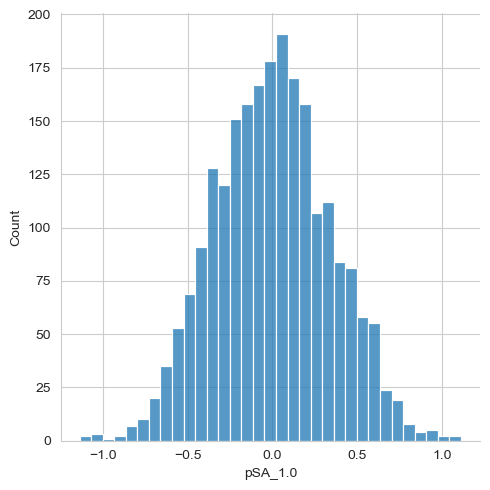

In [30]:
### Within-event residuals for all realisations
sns.displot(cur_wres, x=im);

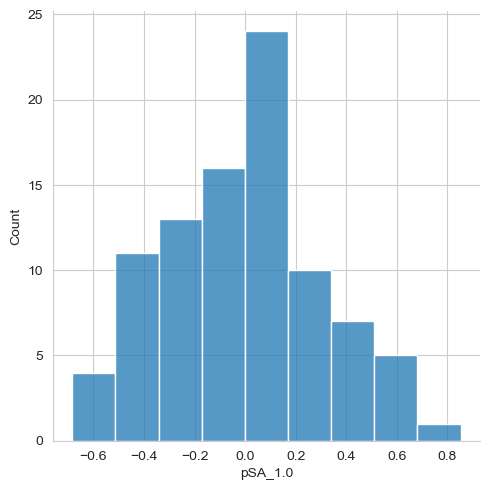

In [26]:
## Within-event residuals for a single realisations
cur_rel_id = "REL01"
cur_df = cur_wres.loc[cur_wres.rel == cur_rel_id]
sns.displot(cur_df, x=im)

In [39]:
### Create aggregate stats df
stats_df = cur_wres[sr.constants.PSA_KEYS].mean(axis=0).to_frame(name="mean")
stats_df["std"] = cur_wres[sr.constants.PSA_KEYS].std(axis=0)
stats_df["period"] = sr.constants.PERIODS

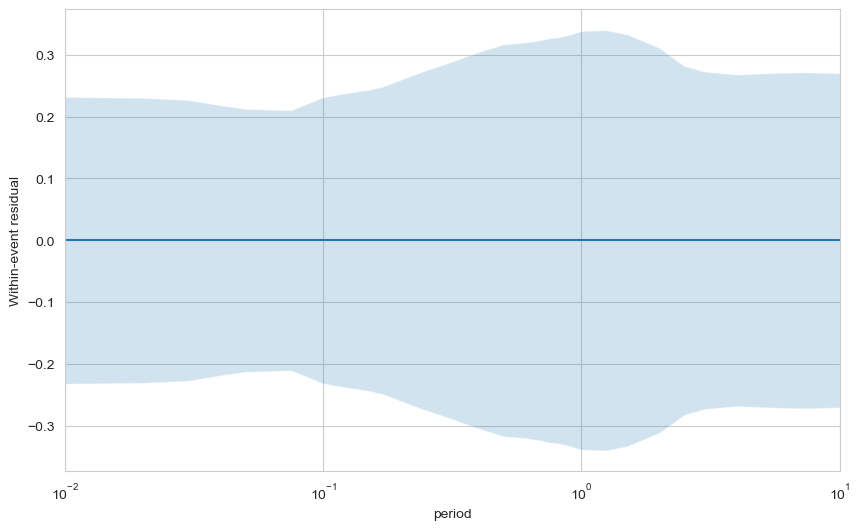

In [54]:
### Within-event residual mean & standard deviation across all realisations
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(stats_df, x="period", y="mean", ax=ax)
ax.fill_between(stats_df["period"], stats_df["mean"] - stats_df["std"], stats_df["mean"] + stats_df["std"], alpha=0.2)
ax.set_xscale("log")
ax.set_xlim(0.01, 10)
ax.set_ylabel("Within-event residual");